# Explore one parcel: Sentinel-2 and Sentinel-1 by identifier and year

**Thesis.** *Geospatial Foundation Models for Transparent Agricultural Monitoring under Label-Scarce Conditions*, David Reyes, ITC, University of Twente.

**What this is.** A working surface, not a report. Give it a EuroCrops parcel identifier and it pulls that parcel's season from the archive, charts it, animates it and puts it beside the EuroCropsML series. Change the number in the first cell of section 2 and everything below follows.

    from gfm4agri.data.parcel_explorer import explore, explore_s1, explore_both

    s2 = explore(21121746)            # chart, animation, comparison
    s1 = explore_s1(21121746)         # backscatter chart and animation
    s2, s1 = explore_both(21121746)   # both, optical overlaid on the radar chart

**Where it comes from.** The vendored `space_time_deepsearch` package ships
`vis.parcel_timeseries.explore`, which does exactly this for Austrian GSA parcels: it looks a parcel up by `KENNUNG` in a GeoPackage, joins the ISV inspection register, and draws five indices with Moran's I plus an NDVI animation. There is **no `explore_s1`** upstream; the radar workflow is `io.sentinel1.parcel_series`, which fetches, clips, reduces in linear power and removes the per-track offset.

`gfm4agri.data.parcel_explorer` supplies both for this thesis's data, keyed by the national identifier of the EuroCrops vector release. It reuses the vendored chart and animation rather than reimplementing them: they need five attributes from the parcel row and an inspection table that is allowed to be empty, so a EuroCrops parcel is presented to them under the names they expect, and the Austrian wording in the header is rewritten afterwards. The Sentinel-1 animation has no upstream counterpart and is written in the same visual language.

**Three corrections are applied that the vendored calls do not make on their own**, all in `gfm4agri.data.sentinel`:

| | what | why it matters |
|---|---|---|
| BOA offset | the reflectance offset is decided **per scene** from its processing baseline, and indices are then computed with `offset=0` | `compute_indices` hard-codes `-1000`, correct only from baseline 04.00 (January 2022). On 2021 data it inflates NDVI by roughly 0.45 |
| cloud screening | SCL classes 0, 1, 3, 8, 9, 10, 11 excluded per pixel, and a date is kept only when 60 % of the parcel survives | the vendored default blacklists nodata, saturated and snow only, so cloud enters the median |
| parcel mask | the reduction is taken over the declared polygon | the loader clips to a bounding box, which for a real parcel includes the neighbours |

## 0. Setup

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from gfm4agri.data.parcel_explorer import (COUNTRY_ID, COUNTRY_NAME, explore, explore_both,
                                           explore_s1, find_parcel)

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
print("identifier column per country:", COUNTRY_ID)
print("outputs are written to results/explore/<country>_<parcel>_<year>/")

identifier column per country: {'EE': 'pollu_id', 'LV': 'PARCEL_ID', 'LT': 'KZS_NR', 'PT': 'OSA_ID'}
outputs are written to results/explore/<country>_<parcel>_<year>/


## 1. Choosing a parcel

Any identifier from the EuroCrops layers works: `pollu_id` for Estonia, `PARCEL_ID` for Latvia, `OSA_ID` for Portugal. Lithuania is the exception and cannot be addressed this way, because it publishes only a field-block number, so an identifier there names a block rather than a parcel.

The country is inferred from the identifier when it is not given. The table below is the set of parcels the crop gallery of notebook 04 selected, which are convenient starting points: mid-sized, compact, and carrying the same HCAT code in both releases.

In [2]:
parcels = pd.read_parquet(REPO / "results/eda/eurocrops/cache/gallery_parcels.parquet")
display(parcels.set_index("crop")[["label", "parcel_id", "hcat", "area_ha", "n_pixels", "compactness"]])

parcel, cc = find_parcel(parcels.loc[0, "parcel_id"])
print(f"lookup check: parcel {parcels.loc[0, 'parcel_id']} is in {COUNTRY_NAME[cc]}, "
      f"declared {parcel.iloc[0]['EC_trans_n']!r} -> HCAT {parcel.iloc[0]['EC_hcat_c']}")

,label,parcel_id,hcat,area_ha,n_pixels,compactness
crop,,,,,,
winter_common_soft_wheat,winter wheat,21121746,3301010101,10.97,1096,0.875
spring_barley,spring barley,20583785,3301010402,9.19,918,0.872
winter_rapeseed_rape,winter rapeseed,21534249,3301060401,17.46,1746,0.865
potatoes,potatoes,21084265,3301030000,13.67,1367,0.828
pasture_meadow_grassland_grass,grassland,21652845,3302000000,13.31,1331,0.911
oats,oats,20908606,3301010500,11.74,1174,0.849


lookup check: parcel 21121746 is in Estonia, declared 'Winter wheat' -> HCAT 3301010101


## 2. Sentinel-2

One call fetches the season, screens it, charts the five indices with Moran's I, animates NDVI with a cursor sweeping the series, and compares against EuroCropsML. The parcel below is winter wheat; change the identifier to follow another field.

Parcel 21121746 (Estonia, 2021)
  crop  : winter common soft wheat (HCAT 3301010101), declared "Winter wheat"
  area  : 10.97 ha, 1,097 pixels at 10 m
  S2    : 2021-03-01 -> 2021-11-15 @10 m ...


  Found 226 candidate Sentinel-2 scenes
  Using EPSG:32635 for projection
  Filtering scenes: Cloud < 70%, Coverage >= 80%...
  Computing local cloud stats...
  Retained 68 scenes after local filtering (max 70%)


  baselines ['2.12', '3.00', '4.00'] via STAC item properties, 1 dates offset-corrected
  SCL blacklist removed: CLOUD_SHADOW 180px, CLOUD medium 2,457px, CLOUD high 2,512px, THIN_CIRRUS 521px, SNOW/ICE 7,576px
  dates : 56 usable, 7 dropped below 60 % clear, median 1099 valid px/date



wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2021/EE_21121746_2021_s2_indices.png


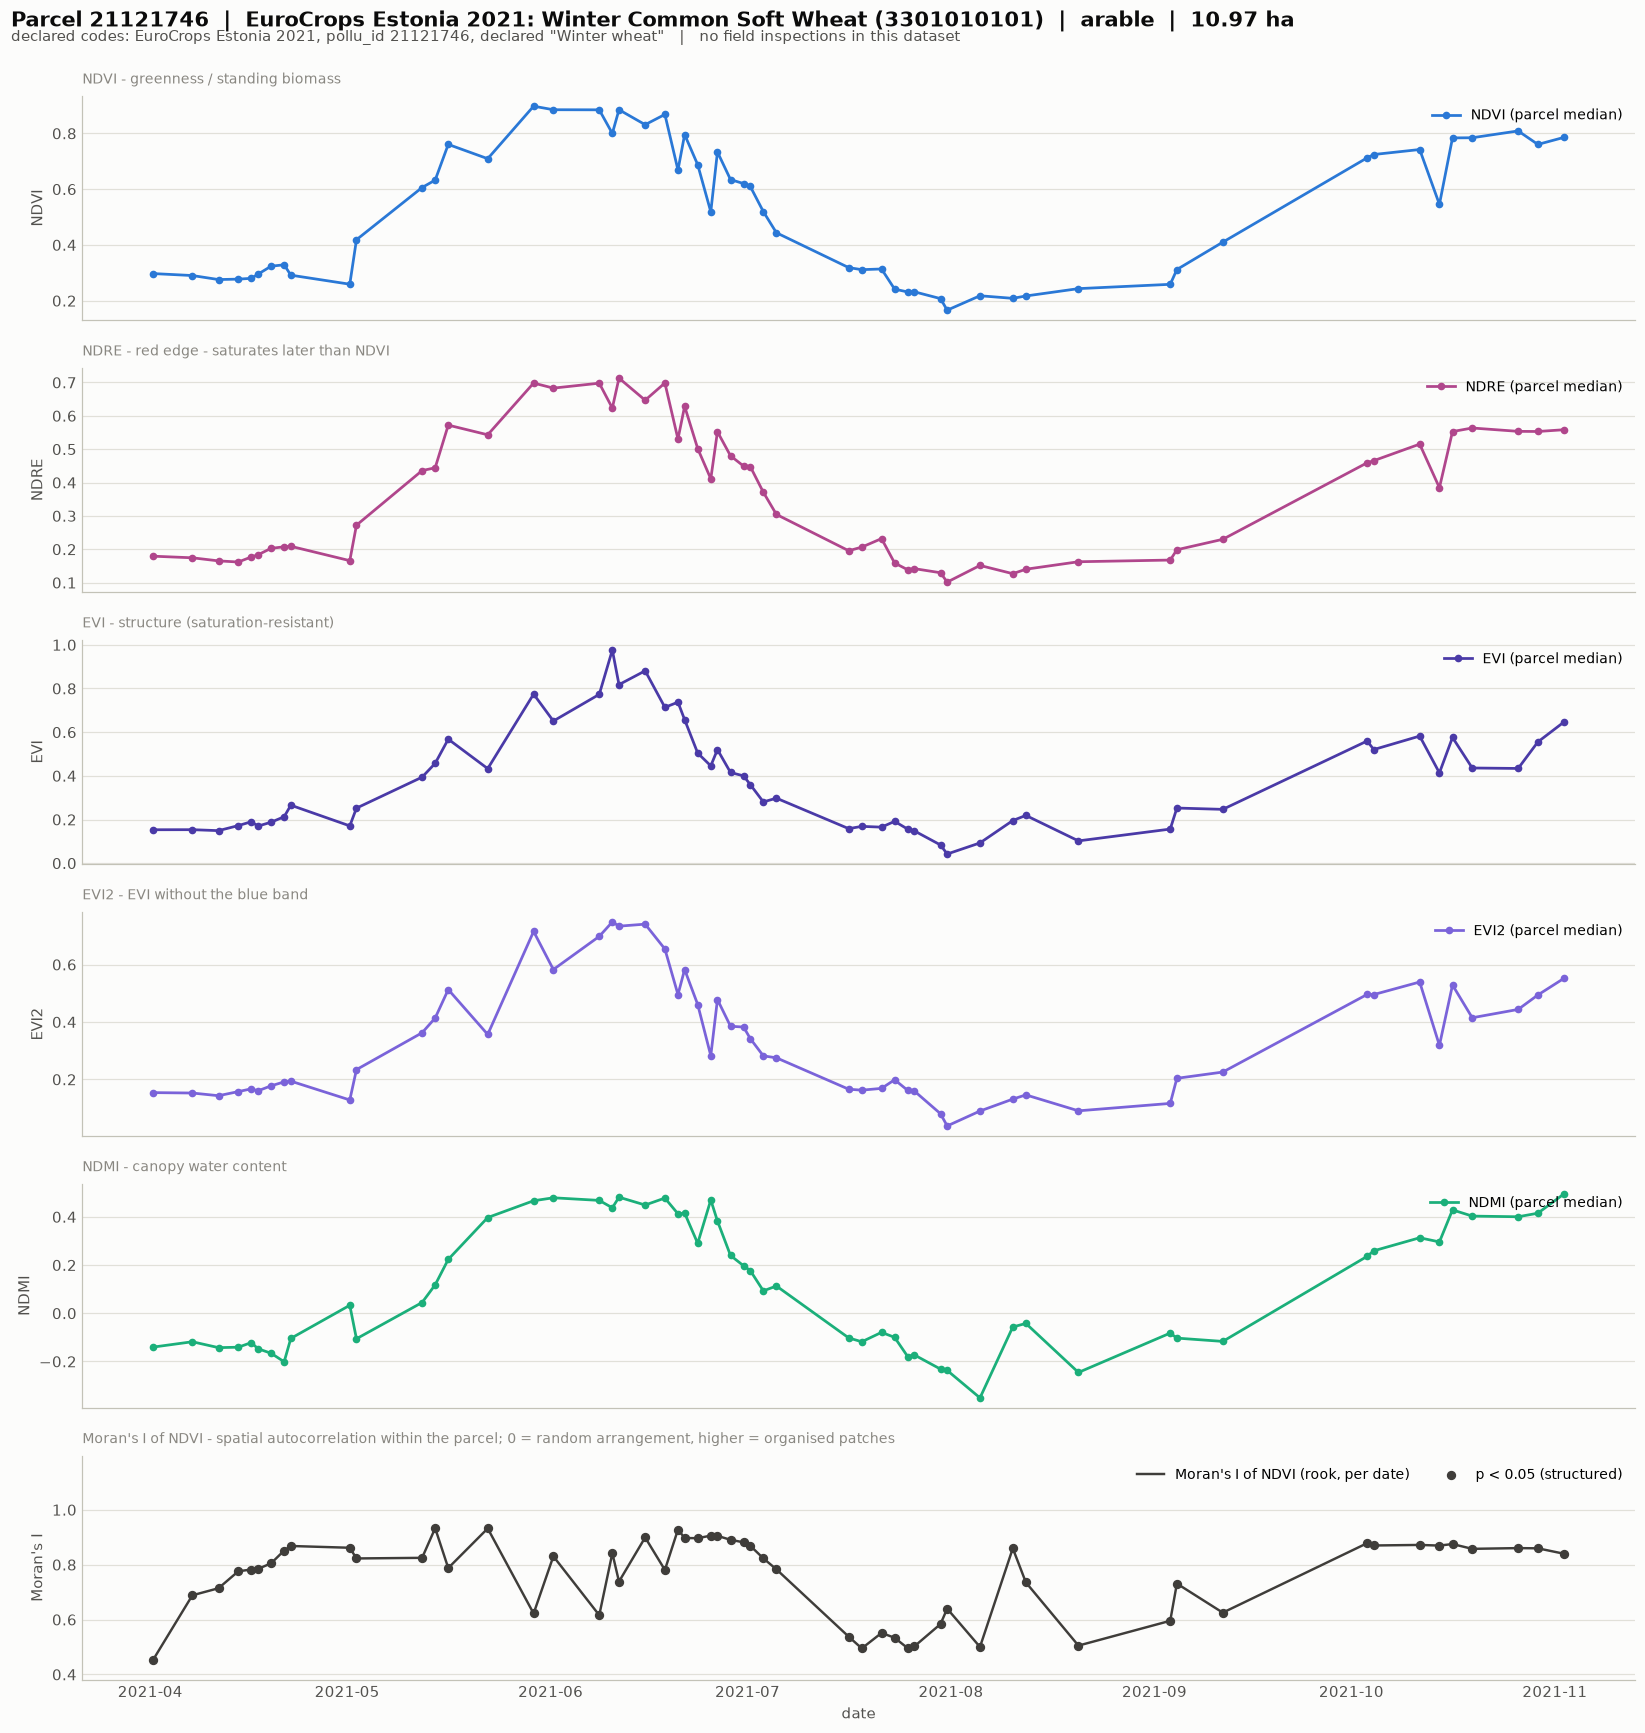

wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2021/EE_21121746_2021_s2_animation.gif  (63 frames @ 2 fps)


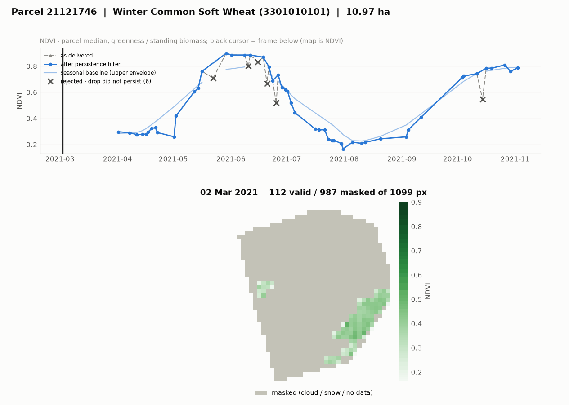

wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2021/EE_21121746_2021_s2_vs_eurocropsml.png


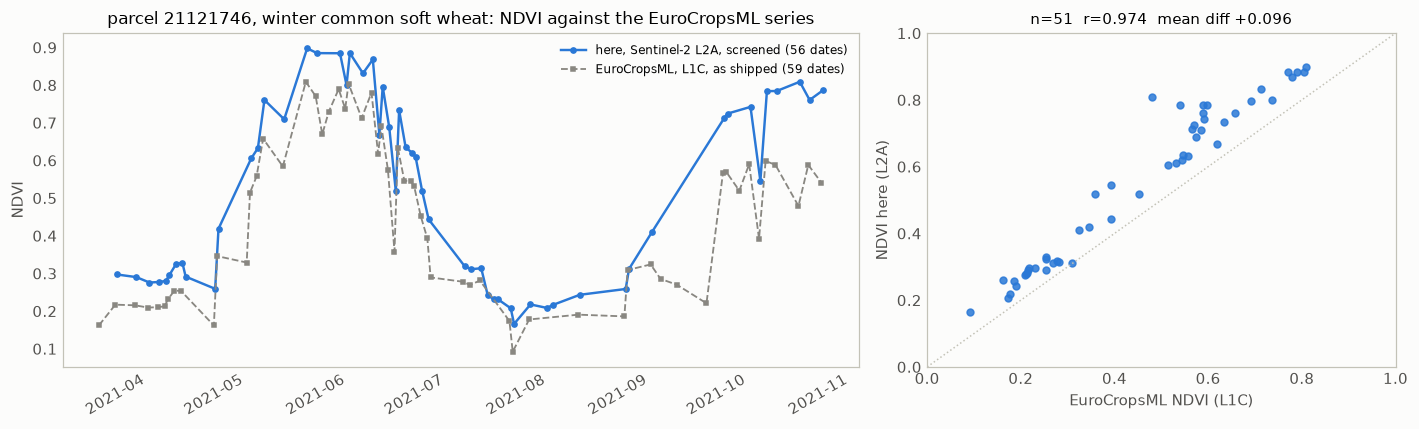

  vs ML : 51 matched dates, r=0.9741, mean difference +0.096 (L2A minus L1C)


In [3]:
PARCEL = 21121746          # winter wheat, Estonia. Change this to explore another parcel.
YEAR = 2021                  # EuroCrops carries one declaration year per country

s2 = explore(PARCEL, YEAR)

The header names the declaration the parcel carries, the panels are the five indices reduced over the polygon, and the bottom panel is Moran's I of NDVI: how spatially organised the field is on each date, which the median cannot show. A hollow marker there means the arrangement is indistinguishable from random.

The animation underneath shows what produced the curve. The map is NDVI per date on a fixed colour scale, the black cursor marks the frame on screen, and the crosses on the series are dates the persistence filter rejected, which is the vendored convention: a drop that does not persist into the next acquisition is more likely cloud than a cut.

In [4]:
print("dates kept:", len(s2.series["NDVI"]), "| dropped by screening:", s2.dates_dropped)
print("processing baselines:", s2.baseline.get("baselines"), "via", s2.baseline.get("baseline_source"))
display(s2.table.head(8))

dates kept: 56 | dropped by screening: 7
processing baselines: ['2.12', '3.00', '4.00'] via STAC item properties


,date,NDVI,NDVI_n_px,NDRE,NDRE_n_px,EVI,EVI_n_px,EVI2,EVI2_n_px,NDMI,NDMI_n_px
0,2021-04-01 09:30:31.024,0.297348,1066,0.179257,1066,0.153120,1066,0.153892,1066,-0.140568,1066
1,2021-04-07 09:50:31.024,0.290255,1082,0.174388,1082,0.153404,1082,0.152505,1082,-0.118245,1082
2,2021-04-11 09:30:31.024,0.275840,1098,0.165145,1098,0.149011,1098,0.143108,1098,-0.142703,1098
3,2021-04-14 09:40:31.024,0.277419,1099,0.161773,1099,0.172082,1099,0.157439,1099,-0.140891,1099
4,2021-04-16 09:30:29.024,0.280191,1038,0.176902,1038,0.189847,1038,0.167093,1038,-0.121758,1038
5,2021-04-17 09:50:21.024,0.295133,1099,0.183369,1099,0.169797,1099,0.160126,1099,-0.147312,1099
6,2021-04-19 09:40:29.024,0.323741,1099,0.202818,1099,0.187650,1099,0.177567,1099,-0.165968,1099
7,2021-04-21 09:30:31.024,0.328789,1099,0.207323,1099,0.212685,1099,0.191300,1099,-0.201432,1099


### 2.1 Against the EuroCropsML series

The same parcel, the same polygon, a different processing level: EuroCropsML reduces **L1C top-of-atmosphere** reflectance, this pull reduces **L2A surface reflectance**. The shapes agree; the levels do not, and the gap is the atmosphere.

In [5]:
print({k: v for k, v in s2.comparison.items() if k != "matched"})

{'dates_l2a_here': 56, 'dates_l1c_eurocropsml': 59, 'matched_dates': 51, 'pearson_r': 0.9741, 'mean_difference': 0.0964, 'rmse': 0.1119, 'max_abs_difference': 0.3297, 'roughness_here': 0.0367, 'roughness_eurocropsml': 0.0601}


Read the two numbers that matter. `pearson_r` says the trajectories are the same trajectory. `mean_difference` is positive because correcting for the atmosphere separates the red and near-infrared bands again and NDVI rises; L1C sits low. `roughness_here` against `roughness_eurocropsml` is the median absolute change between consecutive dates, and the EuroCropsML series is the rougher of the two, which is residual cloud rather than crop.

## 3. Sentinel-1

Radar needs no cloud screening, so the observation record is regular where the optical one is ragged. `parcel_series` fetches the RTC cube, clips it, reduces each date in linear power, and removes the per-track offset; the chart shows both the acquisitions as they arrive and the corrected series, and the animation puts the VH map beside a cursor.

Two settings are not obvious and are handled inside `explore_s1`:

- `min_coverage` is measured over the **bounding box** of the area of interest. A parcel polygon fills only part of its own bounding box, so the value that is sensible for a rectangular area rejects every date. It stays at zero here and the polygon clip does the work.
- Several tracks see the same parcel from different geometries, each with a constant offset of around one decibel. Plotted raw the series is a sawtooth about the orbit rather than the crop, so `normalize_orbit` is applied and the `_adj` columns are what the chart draws.

Parcel 21121746 (Estonia, 2021)
  crop  : winter common soft wheat (HCAT 3301010101)
  S1    : 2021-03-01 -> 2021-11-15 @10 m ...


  Found 149 sentinel-1-rtc scenes; tracks {'87 asc': 39, '160 asc': 39, '80 des': 36, '153 des': 35}; EPSG:32635
  Loading backscatter...
  dates : 149 acquisitions on tracks 80, 87, 153, 160


wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2021/EE_21121746_2021_s1_series.png


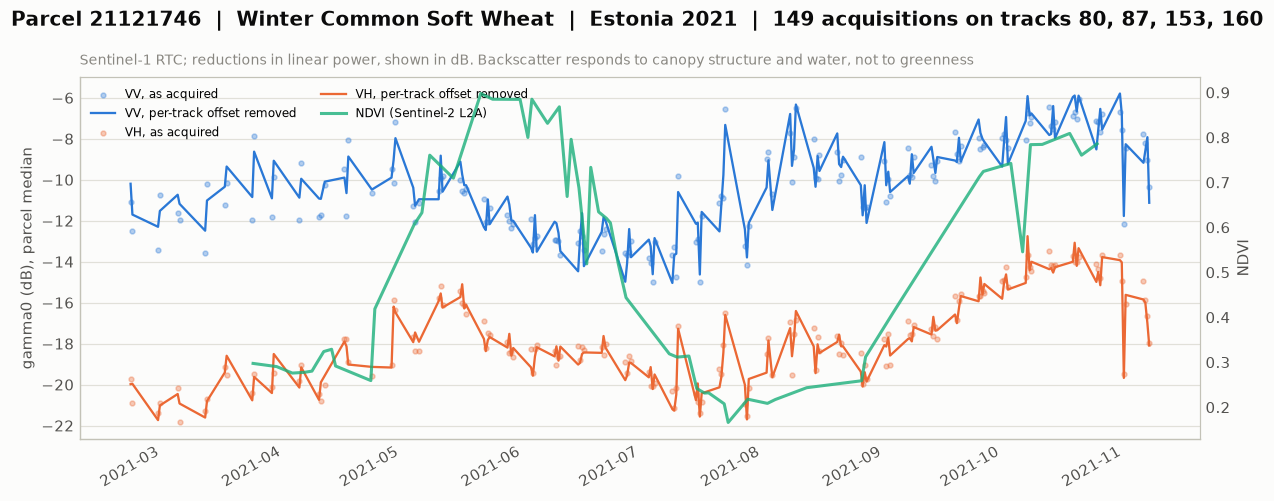

wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2021/EE_21121746_2021_s1_animation.gif  (149 frames @ 2 fps)


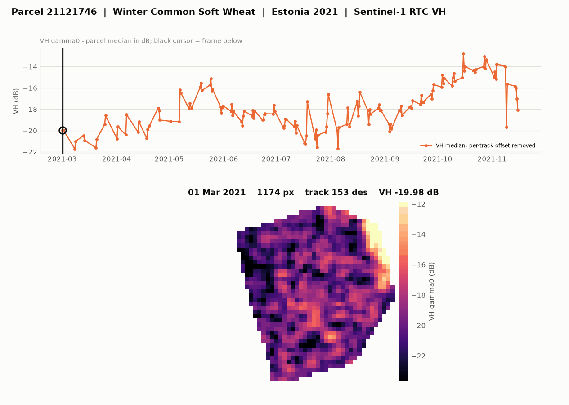

In [6]:
s1 = explore_s1(PARCEL, YEAR, ndvi=s2.series["NDVI"])

In [7]:
print(f"{len(s1.features)} acquisitions on tracks {sorted(set(s1.features['relative_orbit']))}")
display(s1.features.head(6)[["date", "relative_orbit", "orbit_state", "vv_median_db",
                             "vh_median_db", "vh_median_db_adj", "n_pixels"]])

149 acquisitions on tracks [80, 87, 153, 160]


,date,relative_orbit,orbit_state,vv_median_db,vh_median_db,vh_median_db_adj,n_pixels
0,2021-03-01 04:42:28.124257,153,descending,-11.108008,-19.705448,-19.981512,1174
1,2021-03-01 15:57:02.897363,160,ascending,-12.505956,-20.888804,-19.962876,1174
2,2021-03-08 04:34:13.739878,80,descending,-13.409726,-21.390975,-21.734292,1174
3,2021-03-08 15:48:37.337623,87,ascending,-10.738825,-20.903558,-21.020112,1174
4,2021-03-13 04:42:28.202542,153,descending,-11.644983,-20.183010,-20.459074,1174
5,2021-03-13 15:57:02.986126,160,ascending,-11.979880,-21.849231,-20.923303,1174


VH tracks canopy development and falls at harvest, VV carries more of the soil and roughness signal, and both keep responding after NDVI has saturated. For this thesis the point is narrower than "radar is useful": TerraMind takes Sentinel-1 and Sentinel-2 together, so a modality that stays available through cloud is a live option for Phase 1 rather than a curiosity.

## 4. What the call produced

Everything is written to `results/explore/<country>_<parcel>_<year>/`, which is git-ignored, so exploring a hundred parcels costs nothing in the repository. The animations are displayed above through downscaled copies; the full-resolution files are the ones listed here.

In [8]:
out = s2.png.parent
for f in sorted(out.iterdir()):
    print(f"{f.stat().st_size / 1e6:6.2f} MB  {f.name}")

  7.94 MB  EE_21121746_2021_s1_animation.gif
  2.09 MB  EE_21121746_2021_s1_animation_small.gif
  0.07 MB  EE_21121746_2021_s1_features.csv
  0.24 MB  EE_21121746_2021_s1_series.png
  0.00 MB  EE_21121746_2021_s2.json
  3.22 MB  EE_21121746_2021_s2_animation.gif
  0.80 MB  EE_21121746_2021_s2_animation_small.gif
  0.28 MB  EE_21121746_2021_s2_indices.png
  0.15 MB  EE_21121746_2021_s2_vs_eurocropsml.png


## 5. Using it on other parcels

```python
explore(21084265)                       # potatoes, Estonia
explore(21652845, anim_band="NDMI")     # grassland; NDMI is the mowing-sensitive index
explore_s1(21534249, band="vv")         # winter rapeseed, VV instead of VH
explore_both(20583785)                  # spring barley, both sensors in one call

explore(PARCEL, season=("2021-04-01", "2021-09-30"))   # narrow the window
explore(PARCEL, cloud_cover_max=40, min_valid_fraction=0.8)  # stricter screening
explore(PARCEL, animation=False, compare=False)        # chart only, fastest
```

A full season over one parcel costs seconds for the search and a minute or two for the animation, so this is usable interactively while writing the protocol. Two caveats worth carrying: the scene classification layer misses hazy low-sun frames, so a date reported as clear is not always clear; and a parcel carries one declared label for the year, while the imagery may show two canopies when a catch crop or the next winter cereal follows the harvest.